In [5]:
# query_list = ['/home/fingerprint/Data/xiaomi_kuangshi_new/val/001/20200106003848.373-C100-Q080-S990-D1-F0039636413-V0000_000.bmp', '/home/fingerprint/Data/xiaomi_kuangshi_new/val/001/20200106003848.373-C100-Q080-S990-D1-F0039636413-V0000_000.bmp']

In [1]:
import os, sys, time
sys.path.append('../')
sys.path.append('../train')

from PIL import Image
from io import BytesIO
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from train.delf import Delf_V1
from helper.feeder import Feeder
from helper import matcher

def resize_image(image, target_size=224):
    def calc_by_ratio(a, b):
        return int(a * target_size / float(b))

    size = image.size
    if size[0] < size[1]:
        w = calc_by_ratio(size[0], size[1])
        h = target_size
    else:
        w = target_size
        h = calc_by_ratio(size[1], size[0])

    image = image.resize((w, h), Image.BILINEAR)
    return image


def get_and_cache_image(image_path, basewidth=224):
    image = Image.open(image_path)
    if basewidth is not None:
        image = resize_image(image, basewidth)
    imgByteArr = BytesIO()
    image.save(imgByteArr, format='PNG')
    imgByteArr = imgByteArr.getvalue()
    return image, imgByteArr


def get_result(feeder, query):
    pil_image = []
    byte_image = []
    for _, v in enumerate(query):
        pil, byte = get_and_cache_image(v)
        pil_image.append(pil)
        byte_image.append(byte)

    # feed and get output.
    outputs = feeder.feed_to_compare(query, pil_image)
    print('# of extracted feature (qeuery):', len(outputs[0]['descriptor_np_list']))
    print('# of extracted feature (db):', len(outputs[0]['descriptor_np_list']))
    
    att1 = matcher.get_attention_image_byte(outputs[0]['attention_np_list'])
    att2 = matcher.get_attention_image_byte(outputs[1]['attention_np_list'])

    yuantu, side_by_side_comp_img_byte, score,_,_ = matcher.get_ransac_image_byte(
        byte_image[0],
        outputs[0]['location_np_list'],
        outputs[0]['descriptor_np_list'],
        byte_image[1],
        outputs[1]['location_np_list'],
        outputs[1]['descriptor_np_list'])
    print('matching inliner num:', score)
    #print(outputs[0]['location_np_list'])
    #print(outputs[1]['location_np_list'])
    return yuantu, side_by_side_comp_img_byte, att1, att2



In [2]:
import numpy as np
from matplotlib.pyplot import imshow

feeder_config = {
    'GPU_ID': 0,
    'IOU_THRES': 0.98,
    'ATTN_THRES': 0.37,
    'TARGET_LAYER': 'layer3',
    'TOP_K': 1000,
    #'PCA_PARAMETERS_PATH':'../extract/output/pca/res18_mix_enhance_1/pca.h5',
    'PCA_PARAMETERS_PATH':'../extract/output/pca/res18_mix_debase_2/pca.h5',
    #'PCA_PARAMETERS_PATH':'../extract/output/pca/mix_debase_ae/pca.h5',
    'PCA_DIMS':40,
    'USE_PCA': False,
    'SCALE_LIST': [0.25, 0.3535, 0.5, 0.7071, 1.0, 1.4147, 2.0],
    
    #'LOAD_FROM': '../train/repo/res18_mix_enhance_1/keypoint/ckpt/fix.pth.tar',
    #'LOAD_FROM': '../train/repo/mix_debase_ae/keypoint/ckpt/fix.pth.tar',
    'LOAD_FROM': '../train/repo/res18_mix_debase_1/keypoint/ckpt/fix.pth.tar',
    'ARCH': 'resnet18',
    'EXPR': 'dummy',
    'TARGET_LAYER': 'layer3',
}
myfeeder = Feeder(feeder_config)



load DeLF pytorch model...
{'arch': 'resnet18', 'expr': 'dummy', 'load_from': '../train/repo/res18_mix_debase_1/keypoint/ckpt/fix.pth.tar', 'ncls': 'dummy', 'stage': 'inference', 'target_layer': 'layer3', 'use_random_gamma_rescale': False}
[inference] loading resnet18 pretrained ImageNet weights ... It may take few seconds...
deep copied weights from layer "conv1" ...
deep copied weights from layer "bn1" ...
deep copied weights from layer "relu" ...
deep copied weights from layer "maxpool" ...
deep copied weights from layer "layer1" ...
deep copied weights from layer "layer2" ...
deep copied weights from layer "layer3" ...
loaded weights from module "base" ...
loaded weights from module "attn" ...
loaded weights from module "pool" ...
load model from "../train/repo/res18_mix_debase_1/keypoint/ckpt/fix.pth.tar"
load PCA parameters...


../helper/feeder.py:71: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.pca_mean = h5file['.']['pca_mean'].value
../helper/feeder.py:72: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.pca_vars = h5file['.']['pca_vars'].value
../helper/feeder.py:73: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  self.pca_matrix = h5file['.']['pca_matrix'].value


/home/haiqing/anaconda3/envs/sparsencnet/lib/python3.6/site-packages/torch/nn/functional.py:2796: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
/home/haiqing/anaconda3/envs/sparsencnet/lib/python3.6/site-packages/torch/nn/functional.py:2973: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  "See the documentation of nn.Upsample for details.".format(mode))


# of extracted feature (qeuery): 912
# of extracted feature (db): 912
attn_score shape: (1, 1, 14, 14)
attn_score shape: (1, 1, 14, 14)
(82, 2)
matching inliner num: 115


../helper/matcher.py:80: RuntimeWarning: invalid value encountered in true_divide
  cos_sita = (vxi * vxr + vyi * vyr) / np.sqrt(d2i * d2r);
../helper/matcher.py:83: RuntimeWarning: invalid value encountered in true_divide
  ratio = np.minimum(d2i, d2r) / np.maximum(d2i, d2r);
../helper/matcher.py:86: RuntimeWarning: invalid value encountered in less
  c2i = (cos_sita * ratio) < tau


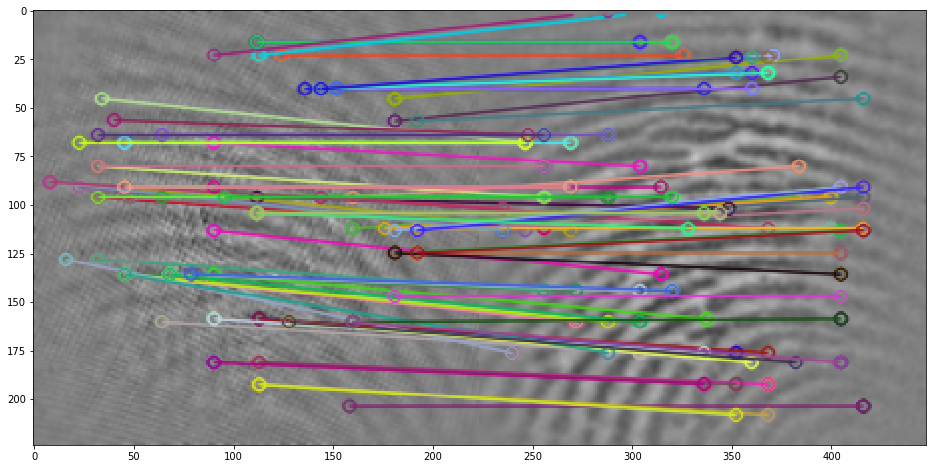

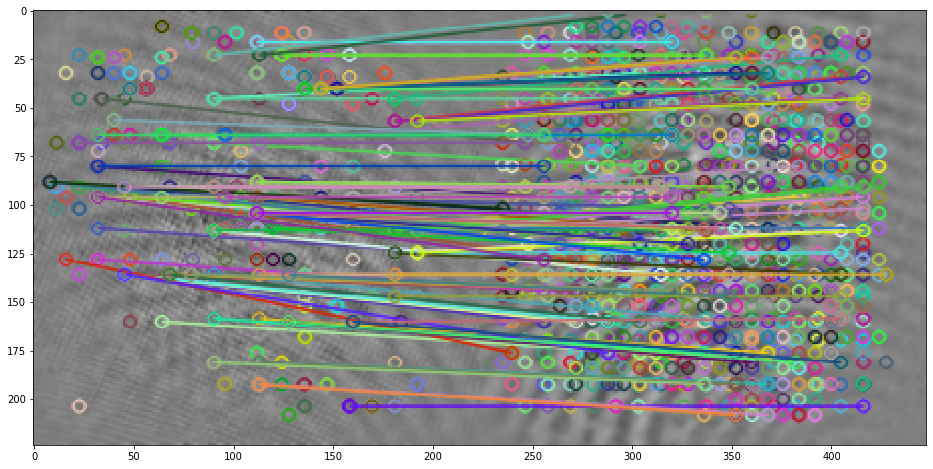

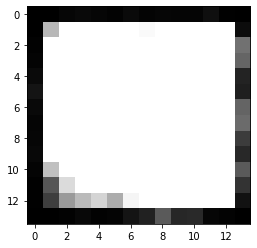

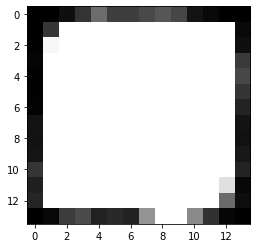

In [5]:

###### bodleian_1.png
# test 1 (1st result with tf code.)
prefix = './'
query = [prefix + '001-3.bmp', prefix + '002-3.bmp']
yuantu_byte, result_image_byte, att1, att2 = get_result(myfeeder, query)
plt.figure(figsize=(16,8))
result_image = Image.open(BytesIO(result_image_byte))
imshow(np.asarray(result_image), aspect='auto')

plt.figure(figsize=(16,8))
yuantu = Image.open(BytesIO(yuantu_byte))
imshow(np.asarray(yuantu), aspect='auto')

plt.figure(figsize=(4,4))
att1_image = Image.open(BytesIO(att1))
imshow(np.asarray(att1_image), aspect='auto')
plt.figure(figsize=(4,4))
att2_image = Image.open(BytesIO(att2))
imshow(np.asarray(att2_image), aspect='auto')
